In [13]:
import numpy as np
from case_studies import *

# https://en.wikipedia.org/wiki/Wolfe_conditions For c_1 and c_2 choice
#def wolfe_line_search(f, df, x, p, c1=1e-4, c2=0.9, max_iter=1000):
#    a = 1.0
#    fx = f(x)
#    grad_x = df(x)
#    for _ in range(max_iter):
#        new_x = x + a * p
#        if f(new_x) > fx + c1 * a * np.dot(p, grad_x):
#            a *= 0.5  # Reduce step size
#        elif np.dot(p, df(new_x)) < c2 * np.dot(p, grad_x):
#            a *= 2.0  # Increase step size
#        else:
#            break
#    return a

def is_pos_def(H):
    return np.all(np.linalg.eigvals(H) > 0)

def backtrack(f, df, x, p, alpha_init=1.0, rho=0.5, c1=1e-4):
    fx = f(x)
    grad_x = df(x)
    alpha = alpha_init
    while f(x + alpha * p) > fx + c1 * alpha * np.dot(grad_x, p):
        alpha *= rho
    return alpha

def steepest_descent(f, df, x0, c1=1e-6, rho=0.5, max_iter=1000):
    x = x0.copy()
    beta = 1.0
    xs=[]
    for _ in range(max_iter):
        p = -df(x) # p_k = −∇f(x_k);
        alpha = backtrack(f, df, x, p, beta, rho=rho, c1=c1) # α_k = backtrack(x_k,p_k,β_k,c_1,ρ);
        x = x + alpha * p # x_{k+1} = x_k + α_k p_k;
        beta = alpha / rho # β_{k+1} = α_k / ρ;
        xs.append(x)
    return xs

def newtons_method(f, df, Hf, x0, c1=1e-6, rho=0.5, max_iter=1000):
    x = x0.copy()
    xs=[]
    for _ in range(max_iter):
        H = Hf(x)
        if is_pos_def(Hf(x)): # if ∇^2 f(x_k) is positive definite then
            p = np.dot(-np.linalg.inv(Hf(x)), df(x)) # p_k = (−∇^2 f(x_k))^{−1} ∇f(x_k)
        else:
            e_values, e_vectors = np.linalg.eigh(Hf(x)) # Compute eigenvalues λ_i and eigenvector v_i of ∇^2 f(xk);
            new_H = np.zeros_like(H)
            for i in range(len(e_values)): # sum_{i=1}^N
                new_H += (1 / np.abs(e_values[i])) * np.dot(e_vectors[:, i], e_vectors[:, i]) # H=1/|λ_i| * v_i.v_i^T
            p = -new_H @ df(x) # p_k = −H^∇ f(x_k)
        a = backtrack(f, df, x, p, 1.0, rho, c1) # α_k = backtrack(x_k,p_k,1.0,c1,ρ);
        x = x + a * p # x_{k+1} = x_k + α_k p_k;
        xs.append(x)
    return xs

x0_f1 = np.random.randn(5)
x0_f2 = np.random.randn(2)
x0_f3 = np.random.randn(5)
x0_f4 = np.random.randn(5)
x0_f5 = np.random.randn(5)

print("Steepest Descent Results:")
print("f1:", steepest_descent(f1, df1, x0_f1)[0])
print("f2:", steepest_descent(f2, df2, x0_f2)[0])
print("f3:", steepest_descent(f3, df3, x0_f3)[0])
print("f4:", steepest_descent(f4, df4, x0_f4)[0])
print("f5:", steepest_descent(f5, df5, x0_f5)[0])

# Running Newton's Method
print("\nNewton's Method Results:")
print("f1:", newtons_method(f1, df1, Hf1, x0_f1)[0])
print("f2:", newtons_method(f2, df2, Hf2, x0_f2)[0])
print("f3:", newtons_method(f3, df3, Hf3, x0_f3)[0])
print("f4:", newtons_method(f4, df4, Hf4, x0_f4)[0])
print("f5:", newtons_method(f5, df5, Hf5, x0_f5)[0])

Steepest Descent Results:
f1: [-1.33327011 -0.50368182 -0.73175259 -0.19290694  0.13088416]
f2: [-0.84621335  0.90105218]
f3: [-0.81164874  0.74008744  0.10611676  0.35333329 -0.20621701]
f4: [0.49666342 0.12895767 0.09143941 4.47041999 0.56876956]
f5: [ 0.          0.01823396 -0.77008264  0.2181683   0.50299075]

Newton's Method Results:
f1: [ 0.00000000e+00  0.00000000e+00 -1.11022302e-16  0.00000000e+00
  0.00000000e+00]
f2: [1.07270842 1.15070325]
f3: [-1.30260468  0.25734942 -0.37770536  0.00907372 -0.16698199]
f4: [ 0.00000000e+00  0.00000000e+00 -7.77368392e-09  0.00000000e+00
  0.00000000e+00]
f5: [ 0.          0.2006017   0.56179308  0.19069606 -0.59030301]


# Eksperimentation

[-47.93486805 -48.47979716]:.2f
[-12.4444493 -32.0754512]:.2f
[-10.32373379 -49.16760485]:.2f
[13.18799271 27.29458129]:.2f


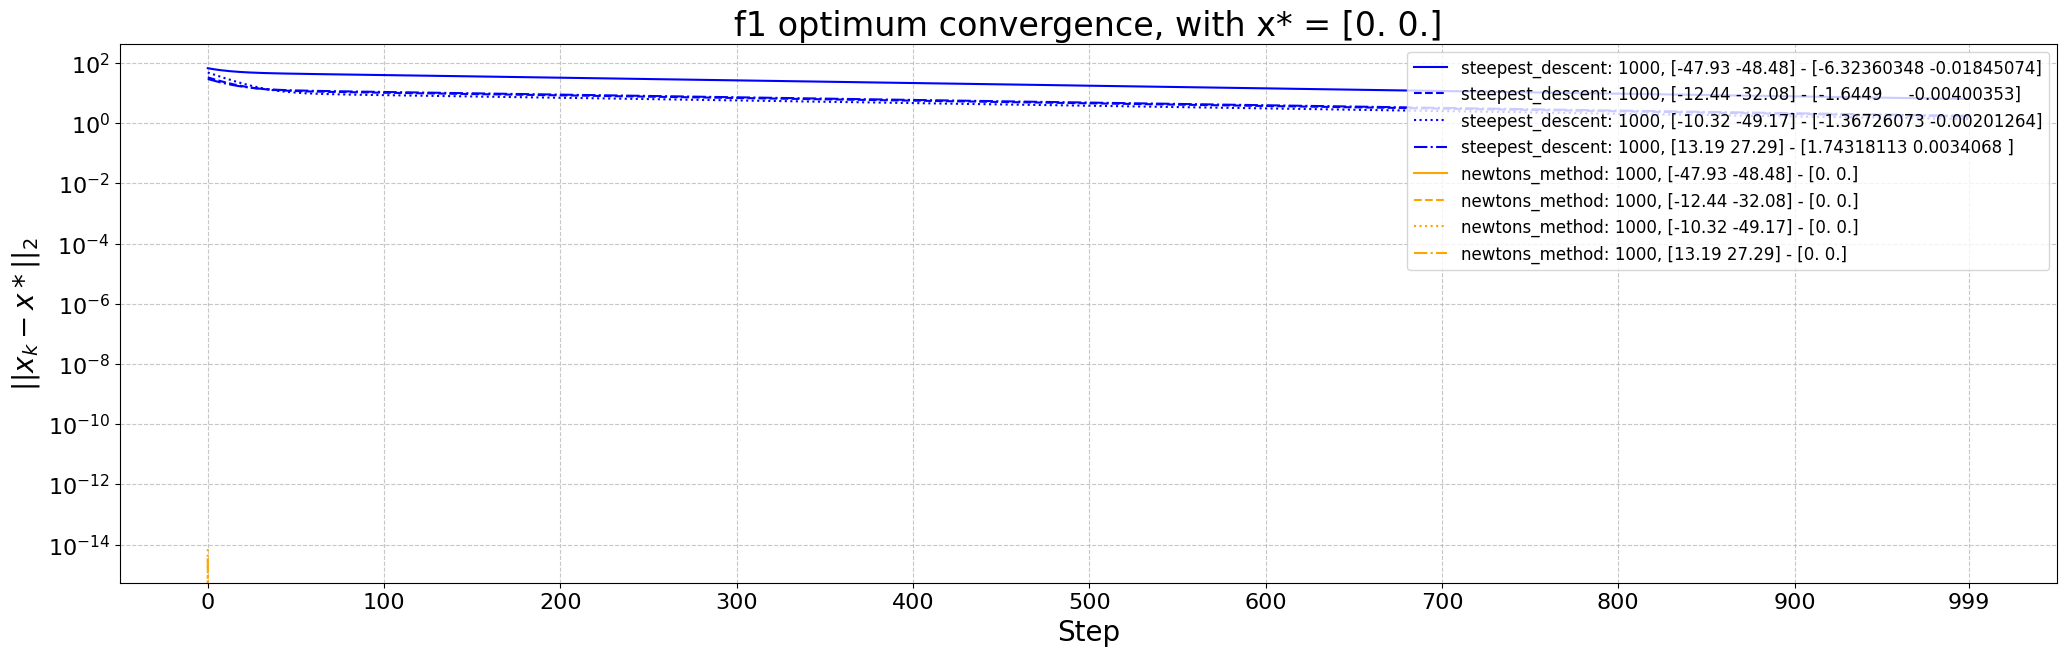

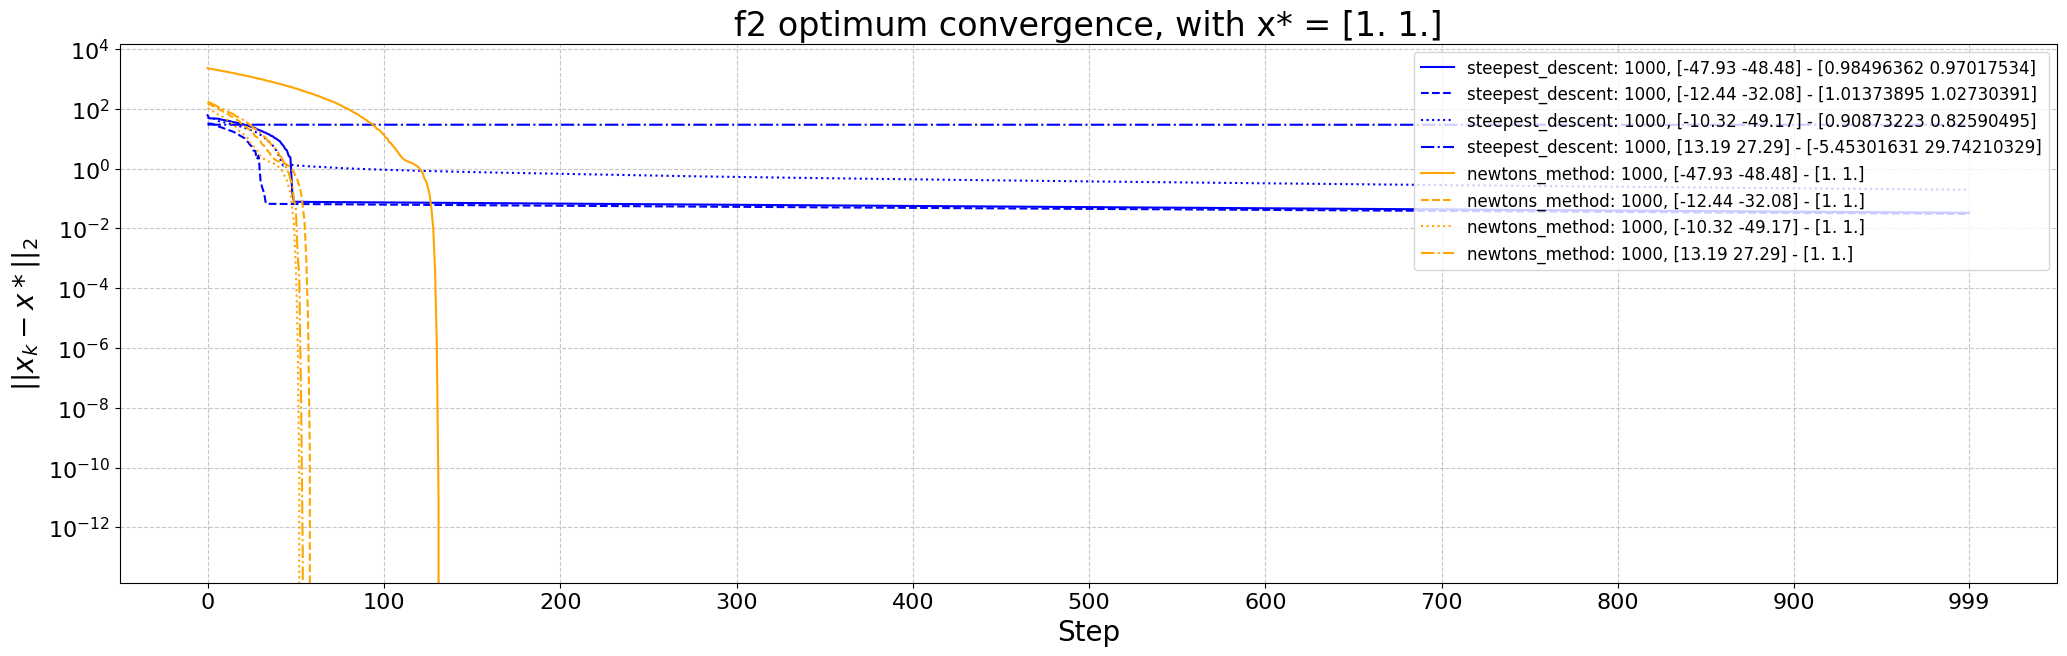

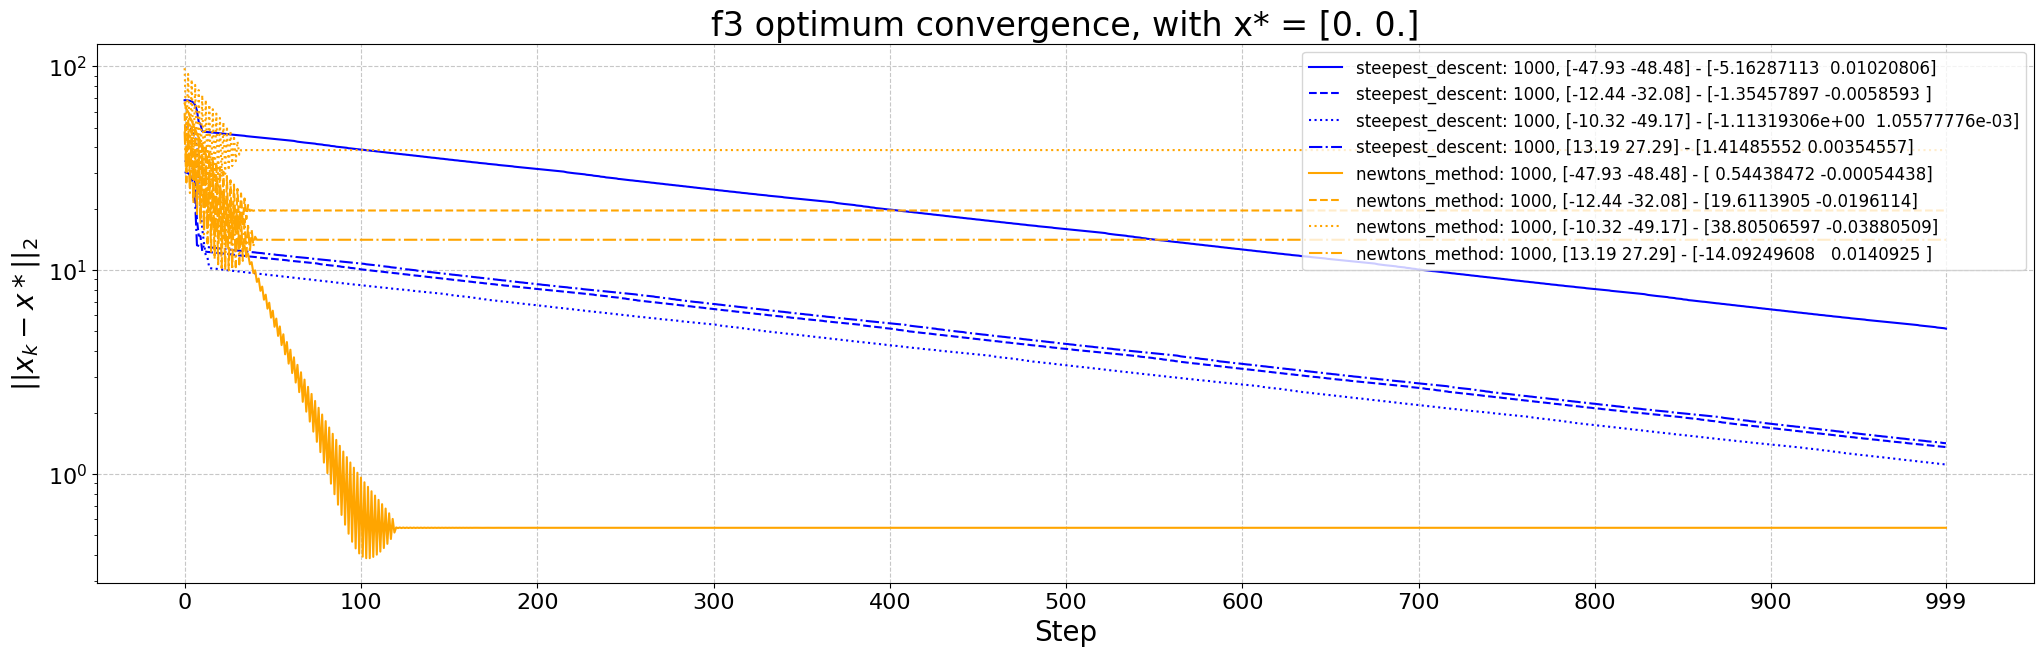

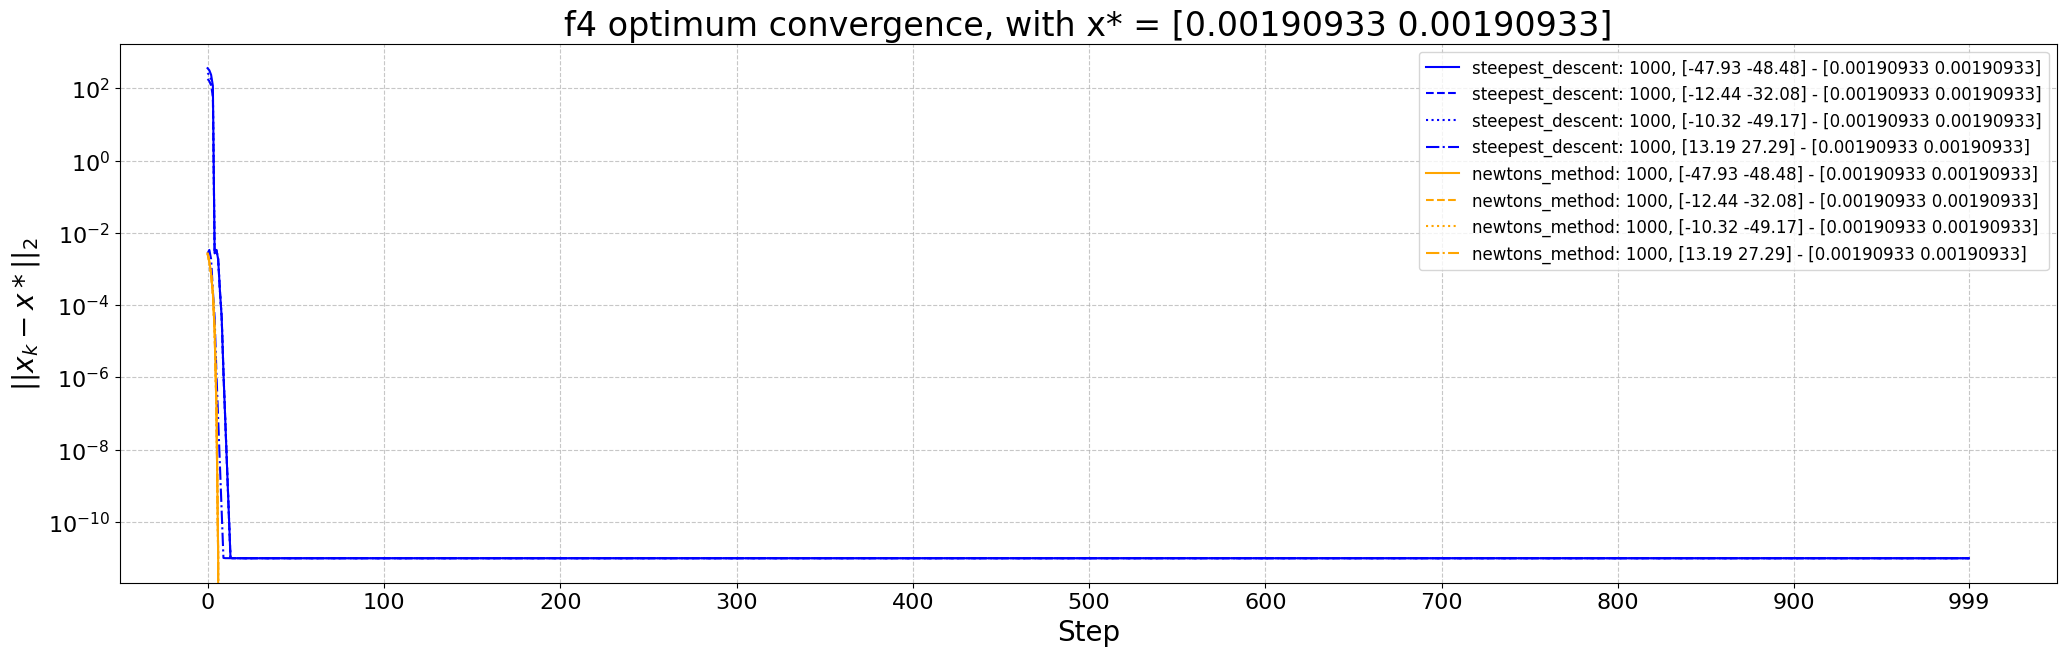

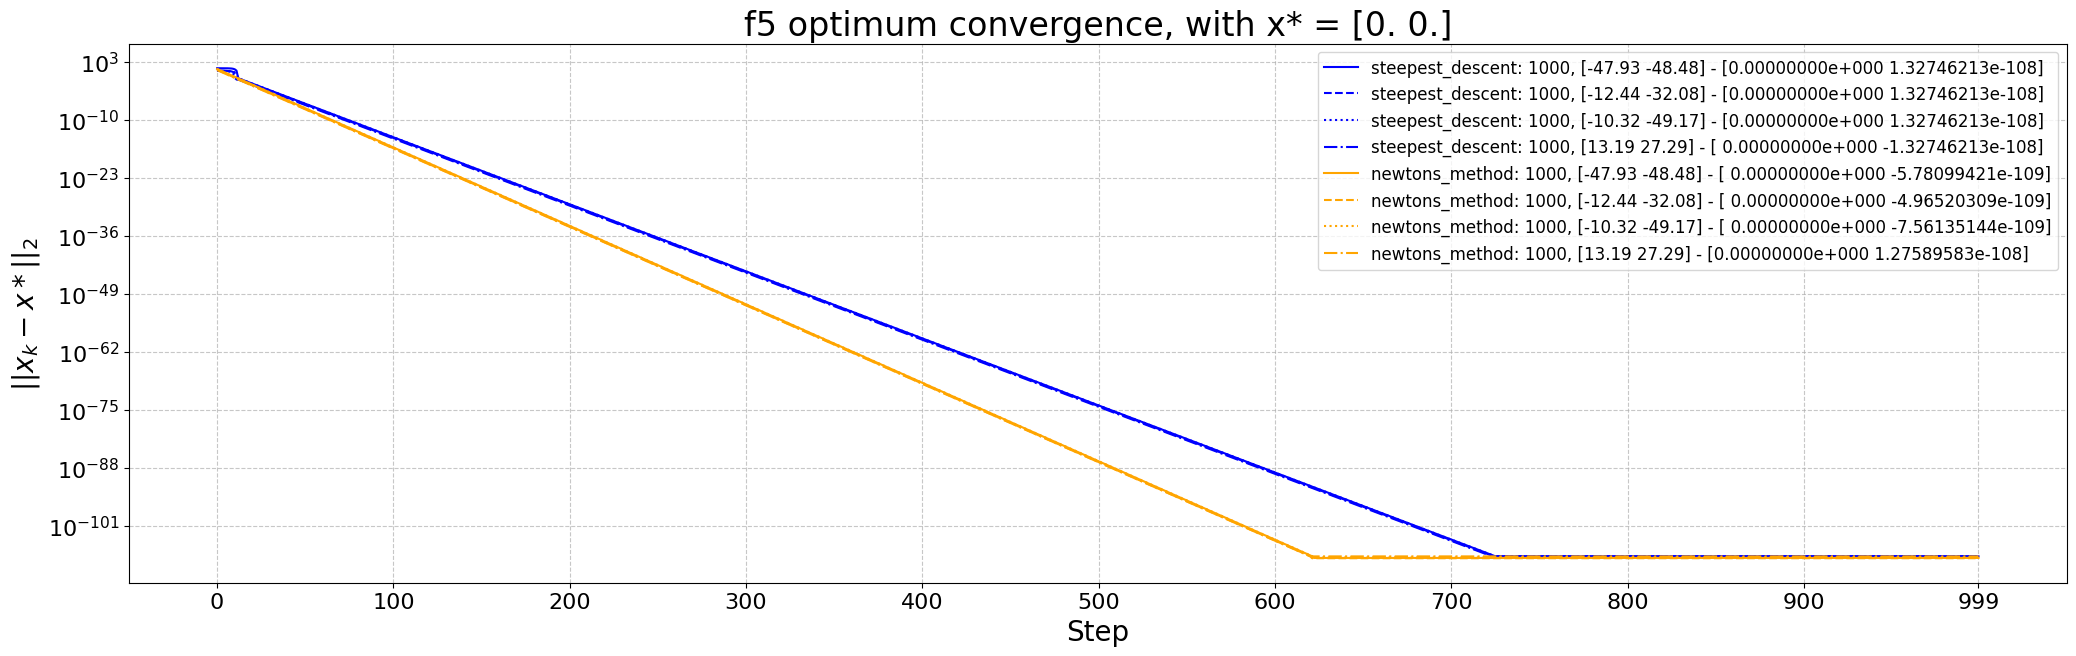

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from case_studies import *

def plot_optimizers(F, O, xs):
    line_styles = ['-', '--', ':', '-.']
    
    for idx, f in enumerate(F, 1):
        plt.figure(figsize=(25, 7))
        plt.yscale("log")
        optimal = x_opt(f[0], 2)
        t = 0
        for o in O:
            for i, x0 in enumerate(xs):
                max_iterations, epsilon = 1000, 1.e-10
                if (o[1] == steepest_descent):
                    xk = o[1](f[1],f[2],x0)             # Change function input / output HERE !!!!!!!!!!!!!!!!!!!!
                else:
                    xk = o[1](f[1],f[2],f[3],x0)        # AND HERE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
                t = (len(xk) if t < len(xk) else t)
                N = [np.linalg.norm(v, ord=2) for v in xk-np.full_like(xk, optimal)]
                label = f"{o[0]}: {len(xk)}, {np.array2string(x0, precision=2)} - {xk[-1]}"
                plt.plot(range(0,len(xk)), N, 
                        label=label, 
                        color=o[2], 
                        linestyle=line_styles[i % len(line_styles)])
        
        plt.legend(loc='upper right', fontsize=12)    
        plt.title(f"{f[0]} optimum convergence, with x* = {optimal}", fontsize=24)
        plt.xlabel("Step", fontsize=20)
        plt.ylabel("$||x_k - x*||_2$", fontsize=20)
        
        # Show only 10 ticks on x-axis
        num_ticks = 10
        step = max(t // num_ticks, 1)
        xticks_positions = list(range(0, t, step))
        if t-1 not in xticks_positions:
            xticks_positions.append(t-1)
        plt.xticks(xticks_positions, xticks_positions, fontsize=16)
        
        # Reduce y-axis grid lines
        plt.gca().yaxis.set_major_locator(plt.LogLocator(numticks=10))
        plt.yticks(fontsize=16)
        
        # Only show major grid lines
        plt.grid(True, which='major', linestyle='--', alpha=0.7)
        plt.grid(False, which='minor')
        plt.show()
        # plt.savefig(f'{idx}.png', bbox_inches='tight', dpi=300)
        # plt.close()

F1 = np.array(["f1", f1, df1, Hf1])
F2 = np.array(["f2", f2, df2, Hf2])
F3 = np.array(["f3", f3, df3, Hf3])
F4 = np.array(["f4", f4, df4, Hf4])
F5 = np.array(["f5", f5, df5, Hf5])
F = np.array([F1, F2, F3, F4, F5])

O1 = np.array(["steepest_descent", steepest_descent, 'blue'])
O2 = np.array(["newtons_method", newtons_method, 'orange'])
O = np.array([O1, O2])

xs = []
for _ in range(4):
    # xs.append(np.random.normal(0, 10, size=2))
    xs.append(np.random.uniform(-50, 50+1, size=2))
    print(f"{xs[-1]}:.2f")  
    # xs.append(np.random.randint(-10, 10+1, size=2))  
    np.ones(2)  

plot_optimizers(F, O, xs)

# Testing Correctness

In [15]:
import numpy as np

# Test functions
functions = {
    "f1": (f1, df1, Hf1, np.array([1.5, -1.5])),
    "f2": (f2, df2, Hf2, np.array([1.5, -1.5])),
    "f3": (f3, df3, Hf3, np.array([1.5, -1.5])),
    "f4": (f4, df4, Hf4, np.array([1.5, -1.5])),
    "f5": (f5, df5, Hf5, np.array([1.5, -1.5])),
}

results = {}
for fname, (f, df, Hf, x0) in functions.items():
    x_sd, iters_sd = steepest_descent(f, df, x0)
    x_newton, iters_newton = newtons_method(f, df, Hf, x0)
    results[fname] = {
        "Steepest Descent Final": x_sd[-1],
        "Steepest Descent Iterations": iters_sd,
        "Newton's Method Final": x_newton[-1],
        "Newton's Method Iterations": iters_newton,
        "Expected": x_opt(fname, len(x0))
    }

results


ValueError: too many values to unpack (expected 2)

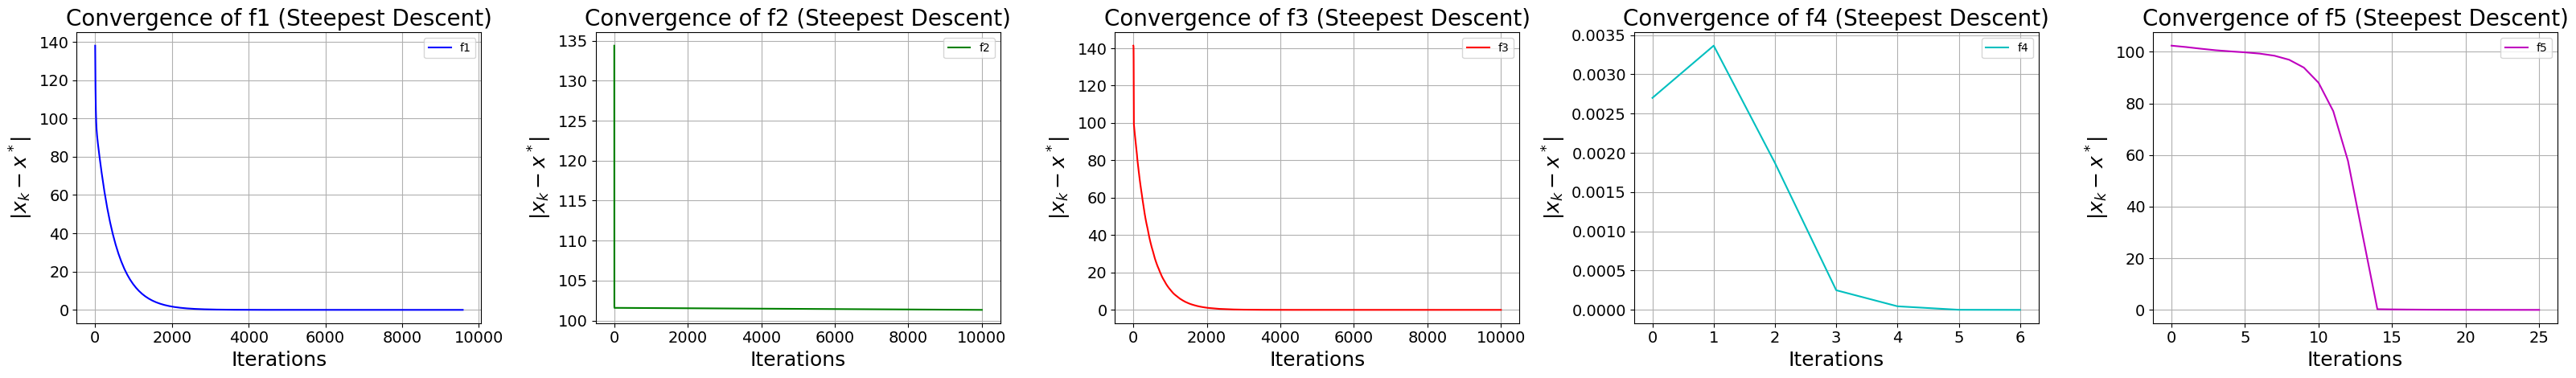

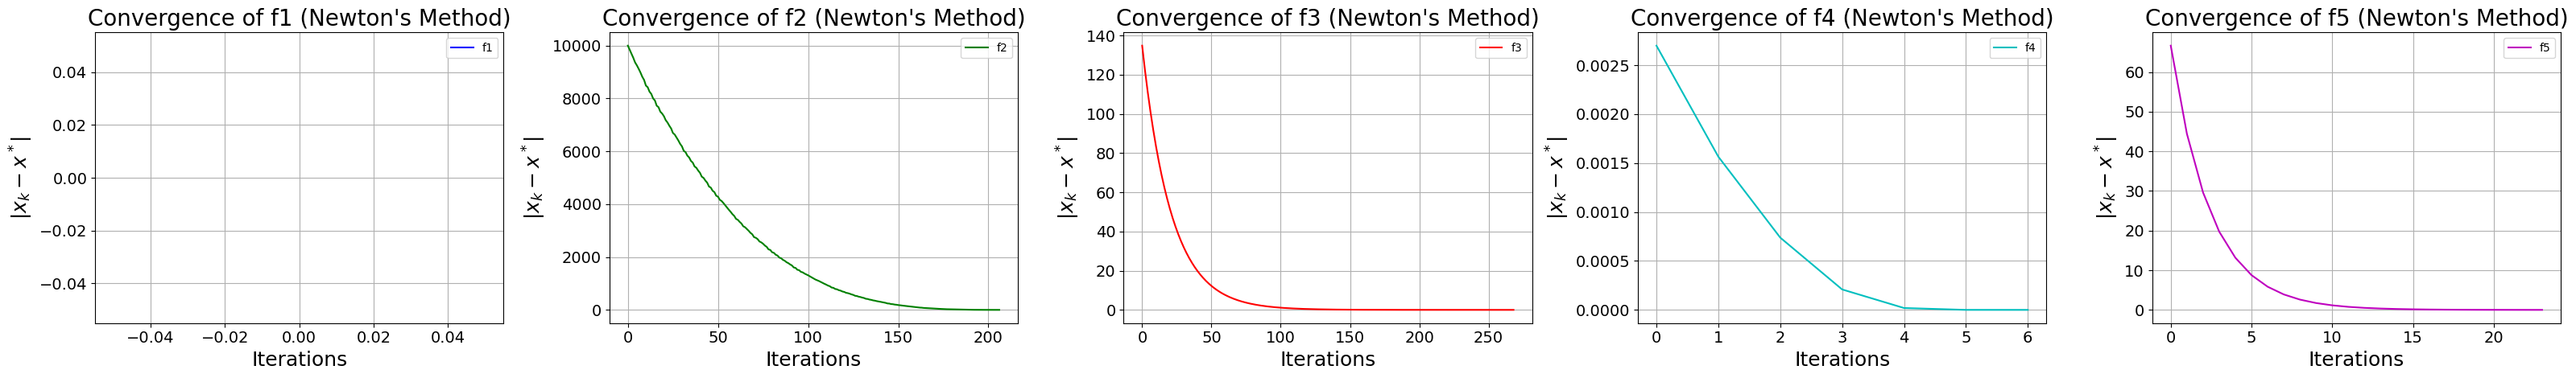

In [ ]:
# Function Setup
functions = [f1, f2, f3, f4, f5]
gradients = [df1, df2, df3, df4, df5]
hessians = [Hf1, Hf2, Hf3, Hf4, Hf5]
names = ["f1", "f2", "f3", "f4", "f5"]
dims = [2, 2, 2, 2, 2]
x0s = [np.array([100.0, 100.0])] * 5

# Parameters
max_iter = 10000
epsilon = 1e-6

# Store convergence data
sd_convergence = []
newton_convergence = []

# Run Steepest Descent and track distance from true x
for i in range(len(functions)):
    f, df = functions[i], gradients[i]
    x_opt_true = x_opt(names[i], dims[i])  # True optimal point
    xs_sd = steepest_descent(f, df, x0s[i], max_iter=max_iter, epsilon=epsilon)
    distance_sd = [np.linalg.norm(x - x_opt_true) for x in xs_sd]  # Distance from true optimal solution
    sd_convergence.append(distance_sd)

# Run Newton's Method and track distance from true x
for i in range(len(functions)):
    f, df, Hf = functions[i], gradients[i], hessians[i]
    x_opt_true = x_opt(names[i], dims[i])  # True optimal point
    xs_newton = newtons_method(f, df, Hf, x0s[i], max_iter=max_iter, epsilon=epsilon)
    distance_newton = [np.linalg.norm(x - x_opt_true) for x in xs_newton]  # Distance from true optimal solution
    newton_convergence.append(distance_newton)

# Define a list of colors
colors = ['b', 'g', 'r', 'c', 'm']  # You can expand or change the color list if needed

# Plot Steepest Descent Convergence (Side by Side)
fig, axes = plt.subplots(1, len(sd_convergence), figsize=(6.4 * len(sd_convergence), 4.8))

for i, (dist, ax) in enumerate(zip(sd_convergence, axes)):
    ax.plot(range(len(dist)), dist, label=f"{names[i]}", color=colors[i])  # Assign color here
    ax.set_xlabel("Iterations", fontsize=18)
    ax.set_ylabel(r"$|x_k - x^*|$", fontsize=18)
    ax.set_title(f"Convergence of {names[i]} (Steepest Descent)", fontsize=20)
    ax.legend()
    ax.grid(True)
    ax.tick_params(axis='x', labelsize=14)  # Set x-axis label size
    ax.tick_params(axis='y', labelsize=14)  # Set y-axis label size

plt.tight_layout()
plt.show()

# Plot Newton's Method Convergence (Side by Side)
fig, axes = plt.subplots(1, len(newton_convergence), figsize=(6.4 * len(newton_convergence), 4.8))

for i, (dist, ax) in enumerate(zip(newton_convergence, axes)):
    ax.plot(range(len(dist)), dist, label=f"{names[i]}", color=colors[i])  # Assign color here
    ax.set_xlabel("Iterations", fontsize=18)
    ax.set_ylabel(r"$|x_k - x^*|$", fontsize=18)
    ax.set_title(f"Convergence of {names[i]} (Newton's Method)", fontsize=20)
    ax.legend()
    ax.grid(True)
    ax.tick_params(axis='x', labelsize=14)  # Set x-axis label size
    ax.tick_params(axis='y', labelsize=14)  # Set y-axis label size

plt.tight_layout()
plt.show()


